In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

# Load and preprocess data
df = pd.read_csv('diabetes.csv')
df.fillna(df.mean(), inplace=True)  # Replace missing values with mean

# Normalize data
scaler = MinMaxScaler()
df[df.columns[:-1]] = scaler.fit_transform(df[df.columns[:-1]])  # Normalize all features except the target

# Split dataset
X = df.drop('Outcome', axis=1)
y = df['Outcome']  # Assuming 'Outcome' is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Distance functions
def euclidean_distance(row1, row2):
    return np.sqrt(np.sum((row1 - row2) ** 2))

def manhattan_distance(row1, row2):
    return np.sum(abs(row1 - row2))

def chebyshev_distance(row1, row2):
    return np.max(abs(row1 - row2))

# Get K nearest neighbors
def get_neighbors(X_train, y_train, test_row, num_neighbors, distance_func):
    distances = []
    for i in range(len(X_train)):
        dist = distance_func(test_row, X_train.iloc[i])
        distances.append((y_train.iloc[i], dist))
    distances.sort(key=lambda x: x[1])
    neighbors = [distances[i][0] for i in range(num_neighbors)]
    return neighbors

# Predict the class
def predict_classification(X_train, y_train, test_row, num_neighbors, distance_func):
    neighbors = get_neighbors(X_train, y_train, test_row, num_neighbors, distance_func)
    prediction = max(set(neighbors), key=neighbors.count)
    return prediction

# Test the KNN model with different distance metrics and K values
metrics = [euclidean_distance, manhattan_distance, chebyshev_distance]
metric_names = ["Euclidean", "Manhattan", "Chebyshev"]
results = []

for distance_func, name in zip(metrics, metric_names):
    for k in range(1, 16):  # Test with K values from 1 to 15
        y_pred = [predict_classification(X_train, y_train, row, num_neighbors=k, distance_func=distance_func) for index, row in X_test.iterrows()]
        accuracy = accuracy_score(y_test, y_pred)
        results.append((name, k, accuracy))
        print(f"Distance: {name}, K: {k}, Accuracy: {accuracy:.4f}")



Distance: Euclidean, K: 1, Accuracy: 0.6688
Distance: Euclidean, K: 2, Accuracy: 0.6818
Distance: Euclidean, K: 3, Accuracy: 0.6948
Distance: Euclidean, K: 4, Accuracy: 0.6688
Distance: Euclidean, K: 5, Accuracy: 0.6883
Distance: Euclidean, K: 6, Accuracy: 0.6818
Distance: Euclidean, K: 7, Accuracy: 0.6753
Distance: Euclidean, K: 8, Accuracy: 0.6948
Distance: Euclidean, K: 9, Accuracy: 0.6948
Distance: Euclidean, K: 10, Accuracy: 0.7143
Distance: Euclidean, K: 11, Accuracy: 0.7208
Distance: Euclidean, K: 12, Accuracy: 0.7273
Distance: Euclidean, K: 13, Accuracy: 0.7273
Distance: Euclidean, K: 14, Accuracy: 0.7143
Distance: Euclidean, K: 15, Accuracy: 0.7273
Distance: Manhattan, K: 1, Accuracy: 0.6753
Distance: Manhattan, K: 2, Accuracy: 0.6818
Distance: Manhattan, K: 3, Accuracy: 0.7078
Distance: Manhattan, K: 4, Accuracy: 0.6883
Distance: Manhattan, K: 5, Accuracy: 0.7013
Distance: Manhattan, K: 6, Accuracy: 0.6688
Distance: Manhattan, K: 7, Accuracy: 0.7078
Distance: Manhattan, K: 8,

In [22]:
# Optionally, you can convert the results into a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['Distance Metric', 'K', 'Accuracy'])
results_df

,Distance Metric,K,Accuracy
0,Euclidean,1,0.668831
1,Euclidean,2,0.681818
2,Euclidean,3,0.694805
3,Euclidean,4,0.668831
4,Euclidean,5,0.688312
5,Euclidean,6,0.681818
6,Euclidean,7,0.675325
7,Euclidean,8,0.694805
8,Euclidean,9,0.694805
9,Euclidean,10,0.714286


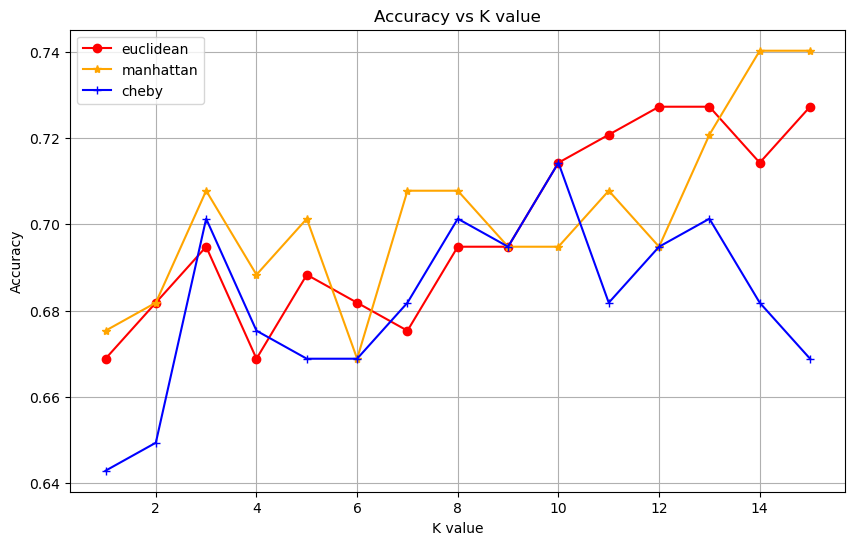

In [25]:
# Optional , if you do its okay
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
resu=results_df[:15]
resu1=results_df[15:30]
resu2=results_df[30:]
plt.plot(resu['K'],resu['Accuracy'],color='red', marker='o',label='euclidean')
plt.plot(resu1['K'],resu1['Accuracy'],color='orange', marker='*',label='manhattan')
plt.plot(resu2['K'],resu2['Accuracy'],color='blue', marker='+',label='cheby')
plt.legend()
plt.title('Accuracy vs K value')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()